# DATA PREPROCESSING

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')


In [50]:
DATA_DIR = "./"

In [51]:
import pandas as pd
# DATA_DIR = "/content/drive/MyDrive/Graph Theory Term Project"

features = pd.read_csv("elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)
labels   = pd.read_csv("elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
edges    = pd.read_csv("elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Edges shape:", edges.shape)

print(features.head())
print(labels.head())
print(edges.head())


print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print("Edges shape:", edges.shape)

print(features.head())
print(labels.head())
print(edges.head())


Features shape: (203769, 167)
Labels shape: (203769, 2)
Edges shape: (234355, 2)
         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.163523  ... -0.511871 -0.400422  0.517257  0.579382   


In [52]:
print(features.info(), end="\n\n")
print(labels.info(), end="\n\n")
print(edges.info(), end="\n\n")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 167 entries, 0 to 166
dtypes: float64(165), int64(2)
memory usage: 259.6 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   txId    203769 non-null  int64 
 1   class   203769 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.1+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234355 entries, 0 to 234354
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   txId1   234355 non-null  int64
 1   txId2   234355 non-null  int64
dtypes: int64(2)
memory usage: 3.6 MB
None



In [53]:
features.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [54]:
features[0].duplicated().sum()

np.int64(0)

In [55]:
edges.duplicated().sum()

np.int64(0)

In [56]:
labels["class"].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [57]:
features = features.rename(columns={0: "txId"})


In [58]:
features.head()

,txId,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [59]:
data = features.merge(labels, on="txId", how="left")

In [60]:
data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [61]:
data["label"] = data["class"].replace({
    "unknown": -1,
    "1": 0,
    "2": 1
}).astype(int)


C:\Users\henry\AppData\Local\Temp\ipykernel_28384\2905946639.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["label"] = data["class"].replace({


In [62]:
node_id_map = {txId: idx for idx, txId in enumerate(data["txId"])}
data["node_index"] = data["txId"].map(node_id_map)

In [63]:
data["label"].unique()

array([-1,  1,  0])

In [64]:
edges["src"] = edges["txId1"].map(node_id_map)
edges["dst"] = edges["txId2"].map(node_id_map)

edges = edges.dropna(subset=["src", "dst"]).astype(int)

edges = edges[["src", "dst"]]


In [65]:
edges.head()

,src,dst
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9


In [66]:
X = data.iloc[:, 1:167].values.astype("float32")
y = data["label"].values.astype(int)

edge_index = edges.values.T

In [67]:
data = data.drop(columns="class")

In [68]:
data.head()

,txId,1,2,3,4,5,6,7,8,9,...,159,160,161,162,163,164,165,166,label,node_index
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1,0
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1,1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,-1,2
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,1,3
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,-1,4


In [69]:
import torch

x = torch.tensor(X, dtype=torch.float32)
edge_index = torch.tensor(edge_index, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)


In [70]:
import torch
import numpy as np
import pandas as pd

# 1. Convert to tensors
x = torch.tensor(X, dtype=torch.float32) 
edge_index = torch.tensor(edge_index, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)


N, F = x.shape 
E = edge_index.shape[1]
print(f"Graph: N={N:,} nodes | E={E:,} directed edges | F={F} node")

# Label distribution
vals, cnts = np.unique(y.cpu().numpy(), return_counts=True)
counts = dict(zip(vals, cnts))
print("Label counts:", counts, "")

# Degree stats
src = edge_index[0].cpu().numpy()
dst = edge_index[1].cpu().numpy()
out_deg = np.bincount(src, minlength=N)
in_deg  = np.bincount(dst, minlength=N)
deg = out_deg + in_deg
isolated = int((deg == 0).sum())

print(f"Degree: mean={deg.mean():.2f}, median={np.median(deg):.2f}, max={deg.max():.0f}")
print(f"Isolated nodes: {isolated:,} ({isolated/N:.2%})")

# Missing in X (Using lowercase 'x' tensor)
missing_total = int(np.isnan(x.cpu().numpy()).sum())
print(f"Missing values in X: {missing_total:,}")

# Edge sanity
self_loops = int((src == dst).sum())
print(f"Self-loops: {self_loops:,}")

Graph: N=203,769 nodes | E=234,355 directed edges | F=166 node
Label counts: {np.int64(-1): np.int64(157205), np.int64(0): np.int64(4545), np.int64(1): np.int64(42019)} 
Degree: mean=2.30, median=2.00, max=473
Isolated nodes: 0 (0.00%)
Missing values in X: 0
Self-loops: 0


C:\Users\henry\AppData\Local\Temp\ipykernel_28384\446334467.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index = torch.tensor(edge_index, dtype=torch.long)
C:\Users\henry\AppData\Local\Temp\ipykernel_28384\446334467.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.long)


In [71]:
num_nodes = y.shape[0]
# Use the temporal column (index 1) which represents the time step
time_steps = torch.tensor(data[1].values)
# Define temporal splits (approx 60/20/20 split of the 49 time steps)
# Train: Steps 1-30
# Val: Steps 31-40
# Test: Steps 41-49
train_mask = (time_steps <= 30) & (y != -1)
val_mask   = (time_steps > 30) & (time_steps <= 40) & (y != -1)
test_mask  = (time_steps > 40) & (y != -1)
print(train_mask.sum(), val_mask.sum(), test_mask.sum())

tensor(26905) tensor(9686) tensor(9973)


In [72]:
from torch_geometric.data import Data

data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

print(data)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

print(data)


Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


In [73]:
SAVE_PATH = f"./elliptic_graph.pt"
torch.save(data, SAVE_PATH)

# BASELINE MODELS

In [74]:
data = torch.load(
    f"elliptic_graph.pt",
    weights_only=False
)
print(data)
print(data.x.shape)
print(data.edge_index.shape)
print(data.y.unique())


Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
torch.Size([203769, 166])
torch.Size([2, 234355])
tensor([-1,  0,  1])


In [75]:
from torch_geometric.loader import DataLoader

loader = DataLoader([data], batch_size=1)

# sanity check
for batch in loader:
    print(batch)
    break


DataBatch(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769], batch=[203769], ptr=[2])


In [76]:
import numpy as np

# Convert tensors to NumPy
X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_idx = data.train_mask.cpu().numpy()
test_idx  = data.test_mask.cpu().numpy()


In [77]:
# Keep only labeled nodes
train_mask = train_idx & (y != -1)
test_mask  = test_idx & (y != -1)

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time


baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

start_train = time.time()

baseline_model.fit(X_train, y_train)

end_train = time.time()
training_time = end_train - start_train

start_inf = time.time()
y_pred = baseline_model.predict(X_test)
end_inf = time.time()
inference_time = end_inf - start_inf

print(f"Total Training Time:  {training_time:.4f} seconds")
print(f"Avg Time Per Epoch:   {training_time/1000:.4f} seconds")
print(f"Inference Time:       {inference_time:.4f} seconds")


Total Training Time:  23.4720 seconds
Avg Time Per Epoch:   0.0235 seconds
Inference Time:       0.0148 seconds


In [79]:
acc = accuracy_score(y_test, y_pred)
f1_illicit = f1_score(y_test, y_pred, pos_label=0)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score (illicit): {f1_illicit:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Logistic Regression Baseline ===
Accuracy: 0.5985
F1-score (illicit): 0.1911

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.90      0.19       524
           1       0.99      0.58      0.73      9449

    accuracy                           0.60      9973
   macro avg       0.55      0.74      0.46      9973
weighted avg       0.94      0.60      0.70      9973



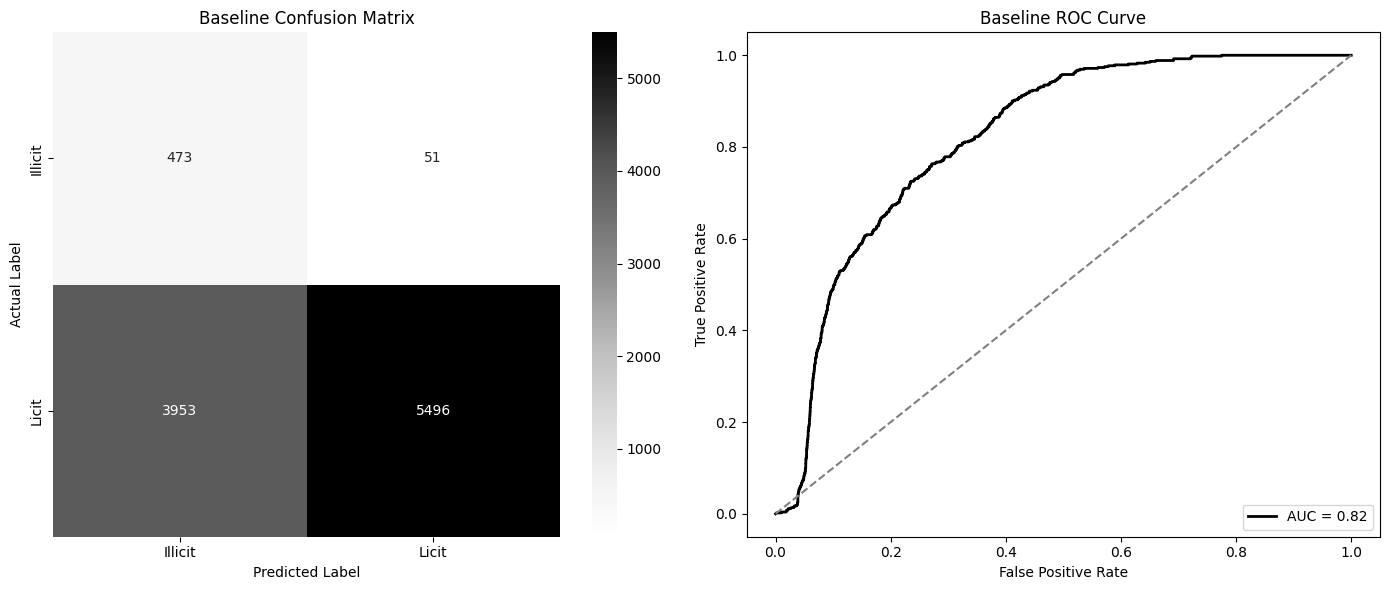

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', ax=axes[0],
            xticklabels=['Illicit', 'Licit'], yticklabels=['Illicit', 'Licit'])
axes[0].set_title('Baseline Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

y_test_bin = (y_test == 0).astype(int) 
fpr, tpr, _ = roc_curve(y_test_bin, y_prob_base)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='black', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('Baseline ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [81]:
print(roc_auc)

0.8202840035578708


# Graph Convolutional Network

In [82]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data = torch.load(f"elliptic_graph.pt", weights_only=False).to(device)
print(data)

MODEL_DIR = f"{DATA_DIR}/models"
import os
os.makedirs(MODEL_DIR, exist_ok=True)

GCN_PATH = f"{MODEL_DIR}/gcn_best.pt"


Device: cuda
Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


In [83]:
import torch.nn as nn

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits


In [84]:
from sklearn.metrics import f1_score, accuracy_score

def masked_metrics(logits, y_true, mask, illicit_label=0):
    pred = logits.argmax(dim=1).detach().cpu().numpy()
    y    = y_true.detach().cpu().numpy()
    m    = mask.detach().cpu().numpy()

    # only labeled nodes inside the chosen split
    idx = m & (y != -1)

    acc = accuracy_score(y[idx], pred[idx])
    f1_illicit = f1_score(y[idx], pred[idx], pos_label=illicit_label)
    return acc, f1_illicit

def train_one_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)  # logits for ALL nodes
    # train only on labeled training nodes
    train_mask = data.train_mask & (data.y != -1)

    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)

    val_acc, val_f1 = masked_metrics(out, data.y, data.val_mask, illicit_label=0)
    test_acc, test_f1 = masked_metrics(out, data.y, data.test_mask, illicit_label=0)

    return val_acc, val_f1, test_acc, test_f1


In [150]:

model = GCN(in_channels=data.num_features, hidden_channels=128, out_channels=2, dropout=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

best_state = None
best_val_f1 = -1
patience = 20
pat_left = patience

start_train = time.time()

for epoch in range(1, 1001):
    loss = train_one_epoch(model, data, optimizer)
    val_acc, val_f1, test_acc, test_f1 = evaluate(model, data)

    if val_f1 > best_val_f1: #I stop training when the model stops improving on the thing I actually care about.
      best_val_f1 = val_f1
      best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
      torch.save(best_state, "gcn_best.pt")
      pat_left = patience

    else:
        pat_left -= 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Val Acc {val_acc:.4f} Val F1(illicit) {val_f1:.4f} | Test Acc {test_acc:.4f} Test F1(illicit) {test_f1:.4f}")

    if pat_left == 0:
        print("Early stopping.")
        break

end_train = time.time()
training_time = end_train - start_train


gcn = GCN(data.num_features, 128, 2).to(device)
gcn.load_state_dict(torch.load(f"gcn_best.pt"))


val_acc, val_f1, test_acc, test_f1 = evaluate(gcn, data)

start_inf = time.time()
with torch.no_grad():
    _ = gcn(data.x, data.edge_index)
end_inf = time.time()
inference_time = end_inf - start_inf

print("=== Best GCN Model ===")
print(f"Val  Acc: {val_acc:.4f} | Val  F1(illicit): {val_f1:.4f}")
print(f"Test Acc: {test_acc:.4f} | Test F1(illicit): {test_f1:.4f}")

print("\n\n")
print(f"Total Training Time:  {training_time:.4f} seconds")
print(f"Avg Time Per Epoch:   {training_time/300:.4f} seconds")
print(f"Inference Time:       {inference_time:.4f} seconds")





Epoch 001 | Loss 1.2449 | Val Acc 0.5498 Val F1(illicit) 0.2840 | Test Acc 0.4492 Test F1(illicit) 0.1527
Epoch 010 | Loss 0.4104 | Val Acc 0.6155 Val F1(illicit) 0.3437 | Test Acc 0.5388 Test F1(illicit) 0.1709
Epoch 020 | Loss 0.3132 | Val Acc 0.6137 Val F1(illicit) 0.3433 | Test Acc 0.5684 Test F1(illicit) 0.1675
Early stopping.
=== Best GCN Model ===
Val  Acc: 0.6881 | Val  F1(illicit): 0.3721
Test Acc: 0.6382 | Test F1(illicit): 0.1921



Total Training Time:  1.7169 seconds
Avg Time Per Epoch:   0.0057 seconds
Inference Time:       0.0151 seconds


C:\Users\henry\AppData\Local\Temp\ipykernel_28384\3006388360.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn.load_state_dict(torch.load(f"gcn_best.pt"))


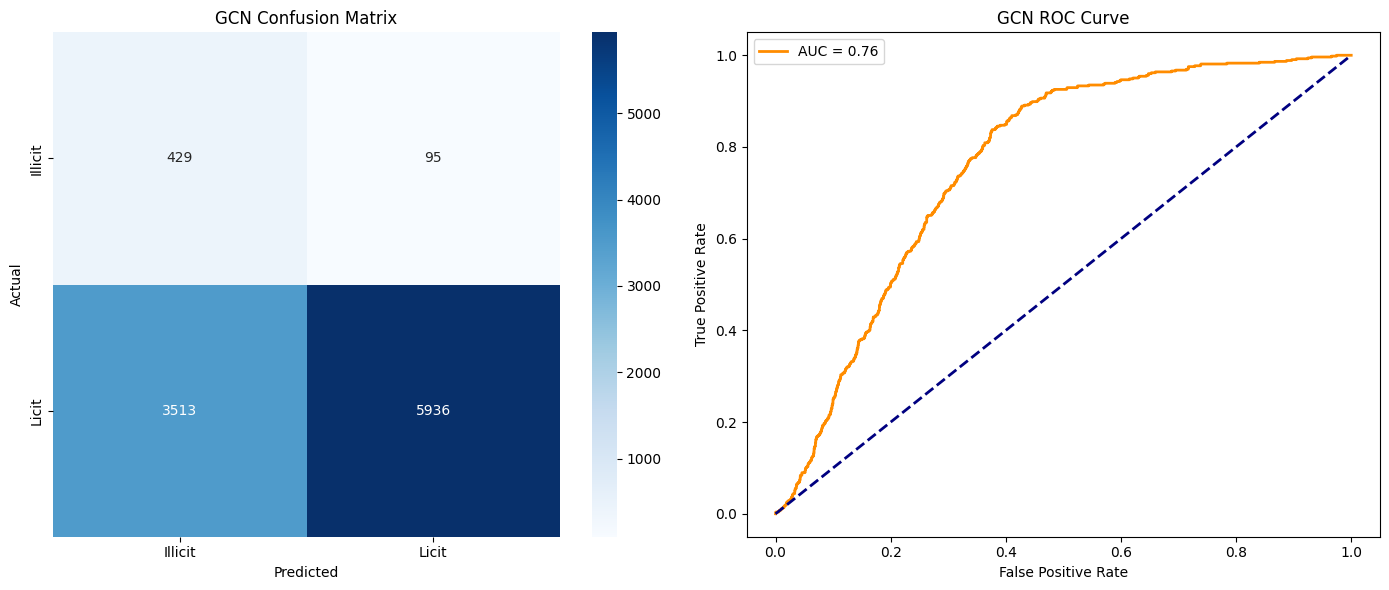

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import torch

gcn.eval()
with torch.no_grad():
    logits = gcn(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 0].cpu().numpy() # Prob of Illicit
    preds = logits.argmax(dim=1).cpu().numpy()

y_true = data.y.cpu().numpy()
test_mask_np = data.test_mask.cpu().numpy() & (y_true != -1)
y_test_vis = y_true[test_mask_np]
preds_test_vis = preds[test_mask_np]
probs_test_vis = probs[test_mask_np]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test_vis, preds_test_vis)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Illicit', 'Licit'], yticklabels=['Illicit', 'Licit'])
axes[0].set_title('GCN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y_test_bin = (y_test_vis == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, probs_test_vis)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('GCN ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# GraphSAGE

In [152]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import SAGEConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data = torch.load(f"{DATA_DIR}/elliptic_graph.pt", weights_only=False).to(device)
print(data)

# model save path
import os
MODEL_DIR = f"{DATA_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)
SAGE_PATH = f"{MODEL_DIR}/graphsage_best.pt"


Device: cuda
Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


In [153]:
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits


In [154]:
from sklearn.metrics import accuracy_score, f1_score

def masked_metrics(logits, y_true, mask, illicit_label=0):
    pred = logits.argmax(dim=1).detach().cpu().numpy()
    y    = y_true.detach().cpu().numpy()
    m    = mask.detach().cpu().numpy()

    idx = m & (y != -1)

    acc = accuracy_score(y[idx], pred[idx])
    f1_illicit = f1_score(y[idx], pred[idx], pos_label=illicit_label)
    return acc, f1_illicit

def train_one_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    train_mask = data.train_mask & (data.y != -1)

    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)

    val_acc, val_f1 = masked_metrics(out, data.y, data.val_mask, illicit_label=0)
    test_acc, test_f1 = masked_metrics(out, data.y, data.test_mask, illicit_label=0)
    return val_acc, val_f1, test_acc, test_f1


In [183]:


model = GraphSAGE(
    in_channels=data.num_features,
    hidden_channels=256,
    out_channels=2,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

best_state = None
best_val_f1 = -1
patience = 20
pat_left = patience

start_train = time.time()
for epoch in range(1, 1001):
    loss = train_one_epoch(model, data, optimizer)
    val_acc, val_f1, test_acc, test_f1 = evaluate(model, data)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, SAGE_PATH)
        pat_left = patience
    else:
        pat_left -= 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} Val F1(illicit) {val_f1:.4f} | "
            f"Test Acc {test_acc:.4f} Test F1(illicit) {test_f1:.4f}"
        )

    if pat_left == 0:
        print("Early stopping.")
        break
end_train = time.time()
training_time = end_train - start_train

sage = GraphSAGE(data.num_features, 256, 2).to(device)
sage.load_state_dict(torch.load(f"models/graphsage_best.pt"))

val_acc, val_f1, test_acc, test_f1 = evaluate(sage, data)

start_inf = time.time()
with torch.no_grad():
    _ = model(data.x, data.edge_index)
end_inf = time.time()
inference_time = end_inf - start_inf


print("=== Best GraphSAGE Model ===")
print(f"Val  Acc: {val_acc:.4f} | Val  F1(illicit): {val_f1:.4f}")
print(f"Test Acc: {test_acc:.4f} | Test F1(illicit): {test_f1:.4f}")

print("\n\n")
print(f"Total Training Time:  {training_time:.4f} seconds")
print(f"Avg Time Per Epoch:   {training_time/300:.4f} seconds")
print(f"Inference Time:       {inference_time:.4f} seconds")




Epoch 001 | Loss 0.7405 | Val Acc 0.5377 Val F1(illicit) 0.3134 | Test Acc 0.3698 Test F1(illicit) 0.1370
Epoch 010 | Loss 0.2726 | Val Acc 0.7087 Val F1(illicit) 0.4140 | Test Acc 0.6734 Test F1(illicit) 0.1884
Epoch 020 | Loss 0.1715 | Val Acc 0.7348 Val F1(illicit) 0.4421 | Test Acc 0.6949 Test F1(illicit) 0.2147
Epoch 030 | Loss 0.1298 | Val Acc 0.8172 Val F1(illicit) 0.5251 | Test Acc 0.8073 Test F1(illicit) 0.2591
Epoch 040 | Loss 0.1071 | Val Acc 0.8335 Val F1(illicit) 0.5481 | Test Acc 0.8326 Test F1(illicit) 0.2797
Epoch 050 | Loss 0.0890 | Val Acc 0.8618 Val F1(illicit) 0.5889 | Test Acc 0.8661 Test F1(illicit) 0.3122
Epoch 060 | Loss 0.0774 | Val Acc 0.8782 Val F1(illicit) 0.6174 | Test Acc 0.8860 Test F1(illicit) 0.3386
Epoch 070 | Loss 0.0717 | Val Acc 0.8862 Val F1(illicit) 0.6334 | Test Acc 0.8969 Test F1(illicit) 0.3599
Epoch 080 | Loss 0.0640 | Val Acc 0.8983 Val F1(illicit) 0.6574 | Test Acc 0.9123 Test F1(illicit) 0.3911
Epoch 090 | Loss 0.0613 | Val Acc 0.8947 Val F

C:\Users\henry\AppData\Local\Temp\ipykernel_28384\1280469372.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sage.load_state_dict(torch.load(f"models/graphsage_best.pt"

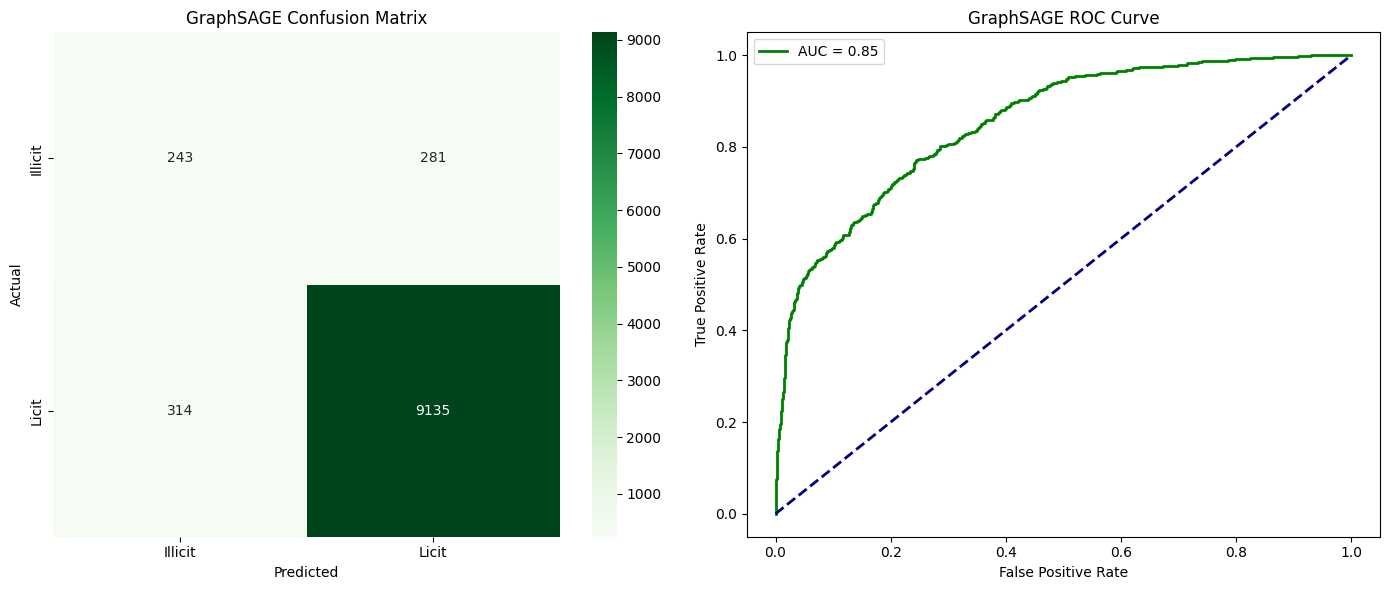

In [184]:
sage.eval()
with torch.no_grad():
    logits = sage(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 0].cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

y_true = data.y.cpu().numpy()
test_mask_np = data.test_mask.cpu().numpy() & (y_true != -1)
y_test_vis = y_true[test_mask_np]
preds_test_vis = preds[test_mask_np]
probs_test_vis = probs[test_mask_np]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_vis, preds_test_vis)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Illicit', 'Licit'], yticklabels=['Illicit', 'Licit'])
axes[0].set_title('GraphSAGE Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y_test_bin = (y_test_vis == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, probs_test_vis)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('GraphSAGE ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# Graph Attention Network

In [162]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from sklearn.metrics import accuracy_score, f1_score
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data = torch.load(f"{DATA_DIR}/elliptic_graph.pt", weights_only=False).to(device)

MODEL_DIR = f"{DATA_DIR}"
os.makedirs(MODEL_DIR, exist_ok=True)
GAT_PATH = f"{MODEL_DIR}/gat_best.pt"


Device: cuda


In [163]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout
        )
        self.conv2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits


In [164]:
# Compute class weights from training data
train_mask = data.train_mask & (data.y != -1)
y_train = data.y[train_mask]

num_illicit = (y_train == 0).sum().item()
num_licit   = (y_train == 1).sum().item()

w_illicit = num_licit / (num_illicit + num_licit)
w_licit   = num_illicit / (num_illicit + num_licit)

class_weights = torch.tensor([w_illicit, w_licit], device=device)

print("Class weights:", class_weights)


Class weights: tensor([0.8902, 0.1098], device='cuda:0')


In [165]:
def masked_metrics(logits, y_true, mask, illicit_label=0):
    pred = logits.argmax(dim=1).detach().cpu().numpy()
    y    = y_true.detach().cpu().numpy()
    m    = mask.detach().cpu().numpy()

    idx = m & (y != -1)

    acc = accuracy_score(y[idx], pred[idx])
    f1_illicit = f1_score(y[idx], pred[idx], pos_label=illicit_label)
    return acc, f1_illicit


def train_one_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    train_mask = data.train_mask & (data.y != -1)

    loss = F.cross_entropy(
        out[train_mask],
        data.y[train_mask],
        weight=class_weights
    )

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)

    val_acc, val_f1 = masked_metrics(out, data.y, data.val_mask, illicit_label=0)
    test_acc, test_f1 = masked_metrics(out, data.y, data.test_mask, illicit_label=0)

    return val_acc, val_f1, test_acc, test_f1


In [166]:
model = GAT(
    in_channels=data.num_features,
    hidden_channels=128,
    out_channels=2,
    heads=2,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,          # LOWER LR
    weight_decay=5e-4
)

best_state = None
best_val_f1 = -1
patience = 20
pat_left = patience


start_train = time.time()
for epoch in range(1, 1001):
    loss = train_one_epoch(model, data, optimizer)
    val_acc, val_f1, test_acc, test_f1 = evaluate(model, data)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, GAT_PATH)
        pat_left = patience
    else:
        pat_left -= 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} Val F1(illicit) {val_f1:.4f} | "
            f"Test Acc {test_acc:.4f} Test F1(illicit) {test_f1:.4f}"
        )

    if pat_left == 0:
        print("Early stopping.")
        break
end_train = time.time()
training_time = end_train - start_train

gat = GAT(data.num_features, 128, 2).to(device)
gat.load_state_dict(torch.load(f"{MODEL_DIR}/gat_best.pt"))

val_acc, val_f1, test_acc, test_f1 = evaluate(gat, data)

start_inf = time.time()
with torch.no_grad():
    _ = model(data.x, data.edge_index)
end_inf = time.time()
inference_time = end_inf - start_inf


print("=== Best GAT Model ===")
print(f"Val  Acc: {val_acc:.4f} | Val  F1(illicit): {val_f1:.4f}")
print(f"Test Acc: {test_acc:.4f} | Test F1(illicit): {test_f1:.4f}")

print("\n\n")
print(f"Total Training Time:  {training_time:.4f} seconds")
print(f"Avg Time Per Epoch:   {training_time/300:.4f} seconds")
print(f"Inference Time:       {inference_time:.4f} seconds")



Epoch 001 | Loss 2.0764 | Val Acc 0.8179 Val F1(illicit) 0.0134 | Test Acc 0.9116 Test F1(illicit) 0.0222
Epoch 010 | Loss 1.0220 | Val Acc 0.4436 Val F1(illicit) 0.2785 | Test Acc 0.2230 Test F1(illicit) 0.1171
Epoch 020 | Loss 0.9307 | Val Acc 0.5387 Val F1(illicit) 0.3141 | Test Acc 0.4009 Test F1(illicit) 0.1446
Epoch 030 | Loss 0.8259 | Val Acc 0.5168 Val F1(illicit) 0.3063 | Test Acc 0.3596 Test F1(illicit) 0.1375
Epoch 040 | Loss 0.7344 | Val Acc 0.5387 Val F1(illicit) 0.3151 | Test Acc 0.4040 Test F1(illicit) 0.1457
Epoch 050 | Loss 0.7327 | Val Acc 0.5321 Val F1(illicit) 0.3123 | Test Acc 0.3964 Test F1(illicit) 0.1444
Epoch 060 | Loss 0.7059 | Val Acc 0.5495 Val F1(illicit) 0.3198 | Test Acc 0.4452 Test F1(illicit) 0.1546
Epoch 070 | Loss 0.6506 | Val Acc 0.5429 Val F1(illicit) 0.3173 | Test Acc 0.4261 Test F1(illicit) 0.1505
Epoch 080 | Loss 0.6540 | Val Acc 0.5426 Val F1(illicit) 0.3172 | Test Acc 0.4228 Test F1(illicit) 0.1498
Epoch 090 | Loss 0.6216 | Val Acc 0.5581 Val F

C:\Users\henry\AppData\Local\Temp\ipykernel_28384\2308773812.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gat.load_state_dict(torch.load(f"{MODEL_DIR}/gat_best.pt"))

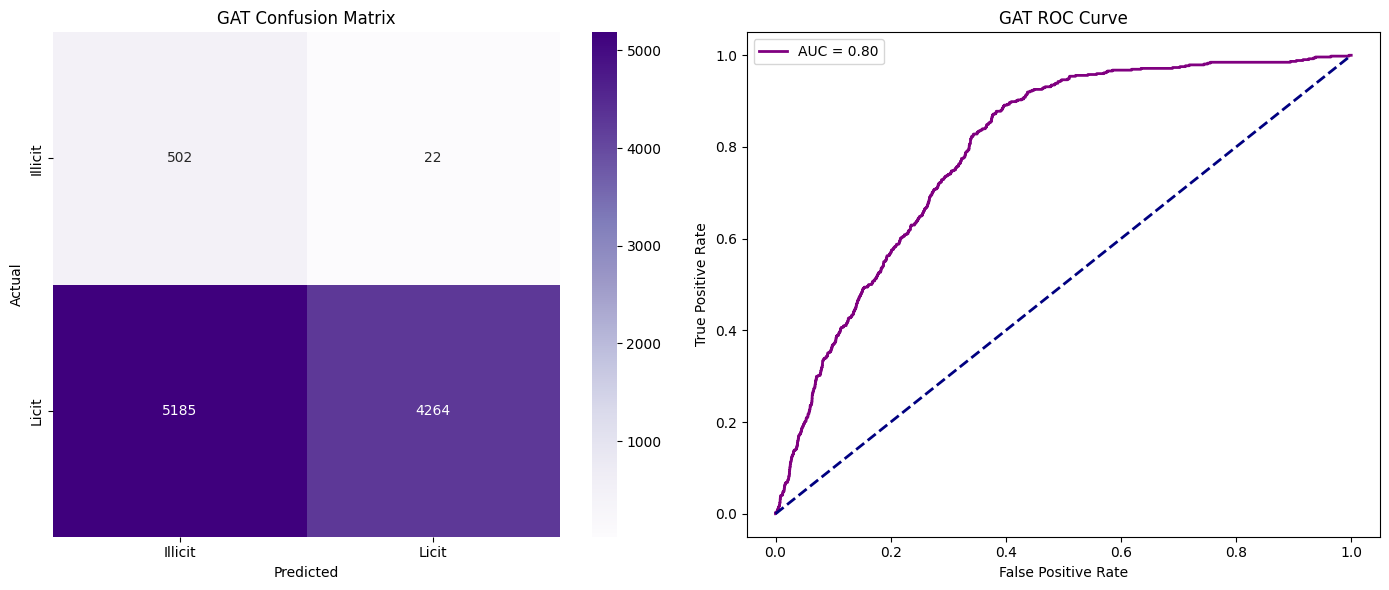

In [167]:
gat.eval()
with torch.no_grad():
    logits = gat(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 0].cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

y_true = data.y.cpu().numpy()
test_mask_np = data.test_mask.cpu().numpy() & (y_true != -1)
y_test_vis = y_true[test_mask_np]
preds_test_vis = preds[test_mask_np]
probs_test_vis = probs[test_mask_np]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test_vis, preds_test_vis)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Illicit', 'Licit'], yticklabels=['Illicit', 'Licit'])
axes[0].set_title('GAT Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y_test_bin = (y_test_vis == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, probs_test_vis)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('GAT ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

#  Graph Isomorphism Network

In [168]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv
from sklearn.metrics import accuracy_score, f1_score
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data = torch.load(f"{DATA_DIR}/elliptic_graph.pt", weights_only=False).to(device)

MODEL_DIR = f"{DATA_DIR}"
os.makedirs(MODEL_DIR, exist_ok=True)
GIN_PATH = f"{MODEL_DIR}/gin_best.pt"


Device: cuda


In [169]:
class GIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )

        nn2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels),
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits


In [170]:
train_mask = data.train_mask & (data.y != -1)
y_train = data.y[train_mask]

num_illicit = (y_train == 0).sum().item()
num_licit   = (y_train == 1).sum().item()

w_illicit = num_licit / (num_illicit + num_licit)
w_licit   = num_illicit / (num_illicit + num_licit)

class_weights = torch.tensor([w_illicit, w_licit], device=device)
print("Class weights:", class_weights)


Class weights: tensor([0.8902, 0.1098], device='cuda:0')


In [171]:
def masked_metrics(logits, y_true, mask, illicit_label=0):
    pred = logits.argmax(dim=1).detach().cpu().numpy()
    y    = y_true.detach().cpu().numpy()
    m    = mask.detach().cpu().numpy()

    idx = m & (y != -1)
    acc = accuracy_score(y[idx], pred[idx])
    f1_illicit = f1_score(y[idx], pred[idx], pos_label=illicit_label)
    return acc, f1_illicit


def train_one_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    train_mask = data.train_mask & (data.y != -1)

    loss = F.cross_entropy(
        out[train_mask],
        data.y[train_mask],
        weight=class_weights
    )

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)

    val_acc, val_f1 = masked_metrics(out, data.y, data.val_mask)
    test_acc, test_f1 = masked_metrics(out, data.y, data.test_mask)
    return val_acc, val_f1, test_acc, test_f1


In [172]:
model = GIN(
    in_channels=data.num_features,
    hidden_channels=128,
    out_channels=2,
    dropout=0.5
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

best_state = None
best_val_f1 = -1
patience = 20
pat_left = patience

start_train = time.time()
for epoch in range(1, 1001):
    loss = train_one_epoch(model, data, optimizer)
    val_acc, val_f1, test_acc, test_f1 = evaluate(model, data)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, GIN_PATH)
        pat_left = patience
    else:
        pat_left -= 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | Loss {loss:.4f} | "
            f"Val Acc {val_acc:.4f} Val F1(illicit) {val_f1:.4f} | "
            f"Test Acc {test_acc:.4f} Test F1(illicit) {test_f1:.4f}"
        )

    if pat_left == 0:
        print("Early stopping.")
        break
end_train = time.time()
training_time = end_train - start_train


gin = GIN(data.num_features, 128, 2).to(device)
gin.load_state_dict(torch.load(f"{MODEL_DIR}/gin_best.pt"))

val_acc, val_f1, test_acc, test_f1 = evaluate(gin, data)

start_inf = time.time()
with torch.no_grad():
    _ = model(data.x, data.edge_index)
end_inf = time.time()
inference_time = end_inf - start_inf

print("=== Best GIN Model ===")
print(f"Val  Acc: {val_acc:.4f} | Val  F1(illicit): {val_f1:.4f}")
print(f"Test Acc: {test_acc:.4f} | Test F1(illicit): {test_f1:.4f}")

print("\n\n")
print(f"Total Training Time:  {training_time:.4f} seconds")
print(f"Avg Time Per Epoch:   {training_time/300:.4f} seconds")
print(f"Inference Time:       {inference_time:.4f} seconds")




Epoch 001 | Loss 0.8288 | Val Acc 0.8896 Val F1(illicit) 0.0000 | Test Acc 0.9474 Test F1(illicit) 0.0000
Epoch 010 | Loss 0.5156 | Val Acc 0.6206 Val F1(illicit) 0.3165 | Test Acc 0.5305 Test F1(illicit) 0.1657
Epoch 020 | Loss 0.4338 | Val Acc 0.6130 Val F1(illicit) 0.3441 | Test Acc 0.5318 Test F1(illicit) 0.1679
Epoch 030 | Loss 0.3797 | Val Acc 0.7324 Val F1(illicit) 0.4106 | Test Acc 0.7199 Test F1(illicit) 0.2139
Epoch 040 | Loss 0.3409 | Val Acc 0.7345 Val F1(illicit) 0.4117 | Test Acc 0.7458 Test F1(illicit) 0.2226
Epoch 050 | Loss 0.3020 | Val Acc 0.7593 Val F1(illicit) 0.4302 | Test Acc 0.7917 Test F1(illicit) 0.2327
Epoch 060 | Loss 0.2766 | Val Acc 0.6994 Val F1(illicit) 0.3923 | Test Acc 0.7067 Test F1(illicit) 0.2058
Epoch 070 | Loss 0.2559 | Val Acc 0.7235 Val F1(illicit) 0.4099 | Test Acc 0.7551 Test F1(illicit) 0.2238
Epoch 080 | Loss 0.2349 | Val Acc 0.7895 Val F1(illicit) 0.4581 | Test Acc 0.8366 Test F1(illicit) 0.2509
Epoch 090 | Loss 0.2202 | Val Acc 0.7552 Val F

C:\Users\henry\AppData\Local\Temp\ipykernel_28384\2492666734.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gin.load_state_dict(torch.load(f"{MODEL_DIR}/gin_best.pt"))

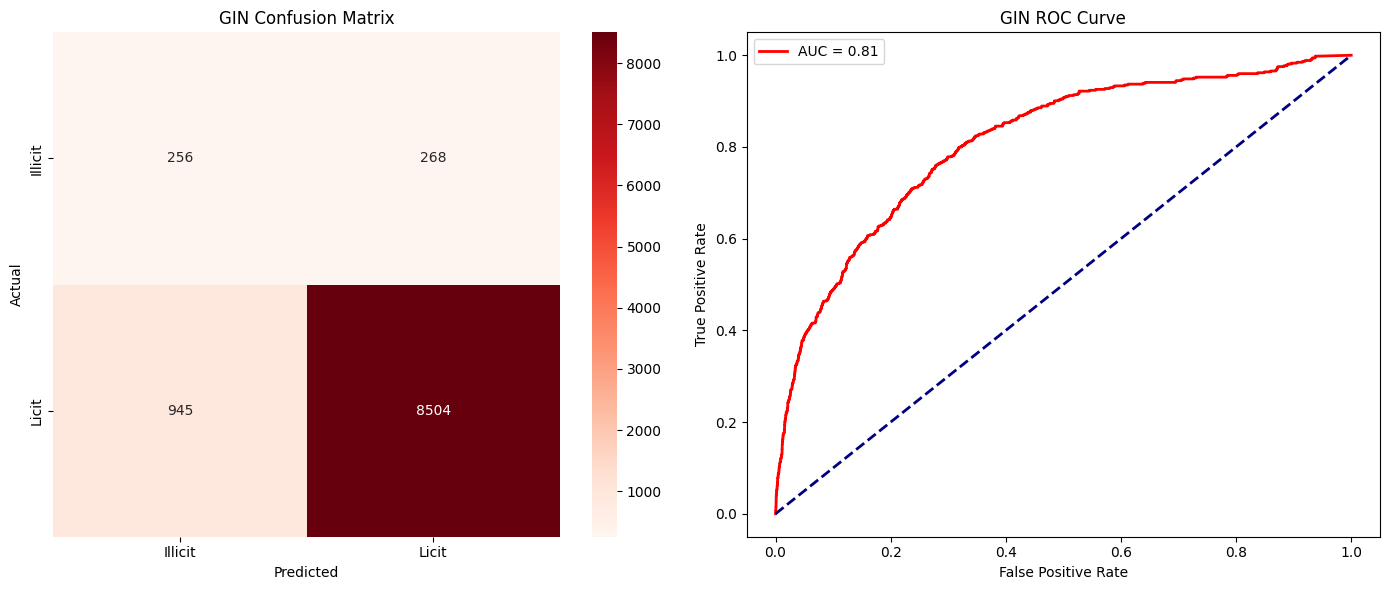

In [173]:

gin.eval()
with torch.no_grad():
    logits = gin(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)[:, 0].cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

y_true = data.y.cpu().numpy()
test_mask_np = data.test_mask.cpu().numpy() & (y_true != -1)
y_test_vis = y_true[test_mask_np]
preds_test_vis = preds[test_mask_np]
probs_test_vis = probs[test_mask_np]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test_vis, preds_test_vis)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Illicit', 'Licit'], yticklabels=['Illicit', 'Licit'])
axes[0].set_title('GIN Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y_test_bin = (y_test_vis == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, probs_test_vis)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='red', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('GIN ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# ROC-AUC

In [174]:
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def compute_roc_auc(model, data):
    model.eval()
    out = model(data.x, data.edge_index)

    # probability of illicit class (class 0)
    probs = torch.softmax(out, dim=1)[:, 0].cpu().numpy()

    y = data.y.cpu().numpy()
    mask = data.test_mask.cpu().numpy()

    idx = mask & (y != -1)

    # flip labels: illicit (0) -> 1, licit (1) -> 0
    y_binary = (y[idx] == 0).astype(int)

    return roc_auc_score(y_binary, probs[idx])



In [175]:
gcn_roc = compute_roc_auc(gcn, data)
print(f"GCN Test ROC-AUC: {gcn_roc:.4f}")


GCN Test ROC-AUC: 0.7619


In [176]:
sage_roc = compute_roc_auc(sage, data)
print(f"GraphSAGE Test ROC-AUC: {sage_roc:.4f}")


GraphSAGE Test ROC-AUC: 0.8244


In [177]:
gat_roc = compute_roc_auc(gat, data)
print(f"GAT Test ROC-AUC: {gat_roc:.4f}")


GAT Test ROC-AUC: 0.7951


In [178]:
gin_roc = compute_roc_auc(gin, data)
print(f"GIN Test ROC-AUC: {gin_roc:.4f}")


GIN Test ROC-AUC: 0.8111


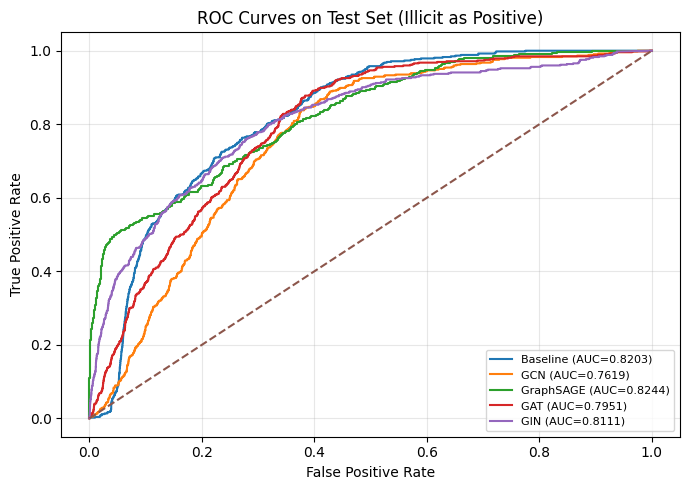

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


y_all = data.y.detach().cpu().numpy()
test_mask_np = (data.test_mask.detach().cpu().numpy()) & (y_all != -1)


y_test_true = y_all[test_mask_np]
y_test_bin = (y_test_true == 0).astype(int)

@torch.no_grad()
def get_prob_illicit(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    probs_illicit = torch.softmax(out, dim=1)[:, 0].detach().cpu().numpy()
    return probs_illicit[test_mask_np]

# Graph models probs on graph test_mask:
p_gcn  = get_prob_illicit(gcn, data)
p_sage = get_prob_illicit(sage, data)
p_gat  = get_prob_illicit(gat, data)
p_gin  = get_prob_illicit(gin, data)

plt.figure(figsize=(7, 5))

# Baseline ROC
y_test_bin_base = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin_base, y_prob_base)
plt.plot(fpr, tpr, label=f"Baseline (AUC={auc(fpr,tpr):.4f})")

for name, p in [
    ("GCN", p_gcn),
    ("GraphSAGE", p_sage),
    ("GAT", p_gat),
    ("GIN", p_gin),
]:
    fpr, tpr, _ = roc_curve(y_test_bin, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.4f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set (Illicit as Positive)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300)
plt.show()


# Optimizers Comparison
To assess the robustness of our best-performing graph model, we will now evaluate the impact of optimizer choice on training dynamics and final performance. Since different optimizers can influence convergence behavior and generalization, we will be comparing Adam, AdamW and SGD on the GraphSAGE architecture to determine whether performance gains are sensitive to optimization strategy rather than model design. This analysis helps distinguish improvements due to architectural choices from those arising purely from optimization effects.

In [143]:
SAGE_ADAMW_PATH = f"{MODEL_DIR}/graphsage_adamw_best.pt"

In [ ]:
# === Add SGD baseline to optimizer comparison (optional but stronger) ===
import copy, time
import torch.nn.functional as F

def train_sage_with_optimizer(opt_name, lr=0.005, weight_decay=5e-4, momentum=0.9, epochs=100, patience=20):
    model = GraphSAGE(in_channels=data.num_features, hidden_channels=128, out_channels=2, dropout=0.5).to(device)

    if opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError("Unknown optimizer")

    best_state, best_val_f1 = None, -1
    bad = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        train_mask = data.train_mask & (data.y != -1)
        loss = F.cross_entropy(out[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
        val_mask = data.val_mask & (data.y != -1)
        val_pred = logits[val_mask].argmax(dim=1).cpu().numpy()
        val_true = data.y[val_mask].cpu().numpy()
        val_f1 = f1_score(val_true, val_pred, pos_label=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    train_time = time.time() - t0
    model.load_state_dict(best_state)

    test_mask = data.test_mask & (data.y != -1)
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
    test_pred = logits[test_mask].argmax(dim=1).cpu().numpy()
    test_true = data.y[test_mask].cpu().numpy()
    test_f1 = f1_score(test_true, test_pred, pos_label=0)

    return best_val_f1, test_f1, train_time

for opt in ["adam", "adamw", "sgd"]:
    v, t, tt = train_sage_with_optimizer(opt)
    print(f"{opt.upper():5s} | best val F1(illicit)={v:.4f} | test F1(illicit)={t:.4f} | train time={tt:.1f}s")


ADAM  | best val F1(illicit)=0.7221 | test F1(illicit)=0.4207 | train time=4.5s
ADAMW | best val F1(illicit)=0.6920 | test F1(illicit)=0.3980 | train time=4.4s
SGD   | best val F1(illicit)=0.3288 | test F1(illicit)=0.1435 | train time=1.9s


# Hyperparameter tuning for GraphSAGE

Testing Hidden Dim: 16
Testing Hidden Dim: 32
Testing Hidden Dim: 64
Testing Hidden Dim: 128
Testing Hidden Dim: 256
Testing Hidden Dim: 512


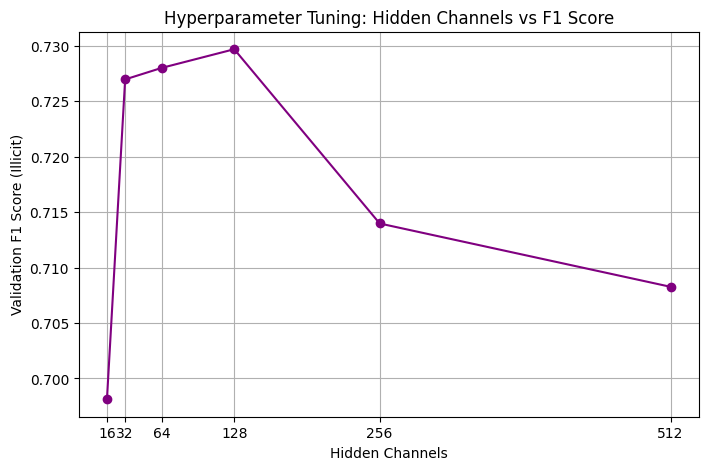

In [180]:
import matplotlib.pyplot as plt

hidden_sizes = [16, 32, 64, 128, 256, 512]
f1_results = []


for h_dim in hidden_sizes:
    print(f"Testing Hidden Dim: {h_dim}")

    model = GraphSAGE(data.num_features, h_dim, 2, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    _, val_f1, _, _ = evaluate(model, data)
    f1_results.append(val_f1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hidden_sizes, f1_results, marker='o', linestyle='-', color='purple')
plt.title('Hyperparameter Tuning: Hidden Channels vs F1 Score')
plt.xlabel('Hidden Channels')
plt.ylabel('Validation F1 Score (Illicit)')
plt.xticks(hidden_sizes)
plt.grid(True)
plt.show()

## Ablation study

In [146]:
# training set size vs test F1 for GraphSAGE
import numpy as np
from copy import deepcopy
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

def eval_masks(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        probs = torch.softmax(out[mask], dim=1).detach().cpu().numpy()
        pred = probs.argmax(axis=1)
        true = data.y[mask].detach().cpu().numpy()

    acc = accuracy_score(true, pred)
    f1_illicit = f1_score((true==0).astype(int), (pred==0).astype(int))
    aucv = roc_auc_score((true==0).astype(int), probs[:,0])
    return acc, f1_illicit, aucv

def graphsage_trainmask(custom_train_mask, hidden_dim=64, lr=0.01, weight_decay=5e-4,
                                         epochs=200, patience=20, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = GraphSAGE(data.num_features, hidden_dim, 2, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_state = None
    best_val_f1 = -1.0
    bad = 0

    val_mask = data.val_mask & (data.y != -1)
    test_mask = data.test_mask & (data.y != -1)

    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[custom_train_mask], data.y[custom_train_mask])
        loss.backward()
        optimizer.step()

        _, val_f1, _ = eval_masks(model, data, val_mask)
        if val_f1 > best_val_f1 + 1e-6:
            best_val_f1 = val_f1
            best_state = deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    acc, f1i, aucv = eval_masks(model, data, test_mask)
    return acc, f1i, aucv

# Labeled train indices
train_mask_labeled = data.train_mask & (data.y != -1)
train_idx = torch.where(train_mask_labeled)[0].detach().cpu().numpy()

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
seeds = [0, 1, 2, 3, 4]

results = {f: {"acc": [], "f1": [], "auc": []} for f in fractions}

for f in fractions:
    k = int(len(train_idx) * f)
    for sd in seeds:
        rng = np.random.default_rng(sd)
        chosen = rng.choice(train_idx, size=k, replace=False)
        custom_mask = torch.zeros_like(data.train_mask, dtype=torch.bool)
        custom_mask[torch.tensor(chosen, device=device)] = True

        acc, f1i, aucv = graphsage_trainmask(custom_mask, hidden_dim=64, seed=sd)
        results[f]["acc"].append(acc)
        results[f]["f1"].append(f1i)
        results[f]["auc"].append(aucv)

print("=== Ablation: train-set size (GraphSAGE) ===")
for f in fractions:
    print(f"fraction={f:.1f} | F1(illicit)={np.mean(results[f]['f1']):.4f}±{np.std(results[f]['f1']):.4f} "
          f"| AUC={np.mean(results[f]['auc']):.4f}±{np.std(results[f]['auc']):.4f}")

x = np.array(fractions)
f1_mean = np.array([np.mean(results[f]["f1"]) for f in fractions])
f1_std  = np.array([np.std(results[f]["f1"]) for f in fractions])

plt.figure(figsize=(7,5))
plt.errorbar(x, f1_mean, yerr=f1_std, fmt='-o', capsize=4)
plt.xlabel("Fraction of labeled training nodes used")
plt.ylabel("Test F1 (illicit)")
plt.title("Ablation: Training set size vs illicit F1 (GraphSAGE)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_train_size_sage.png", dpi=300)
plt.show()


KeyboardInterrupt: 

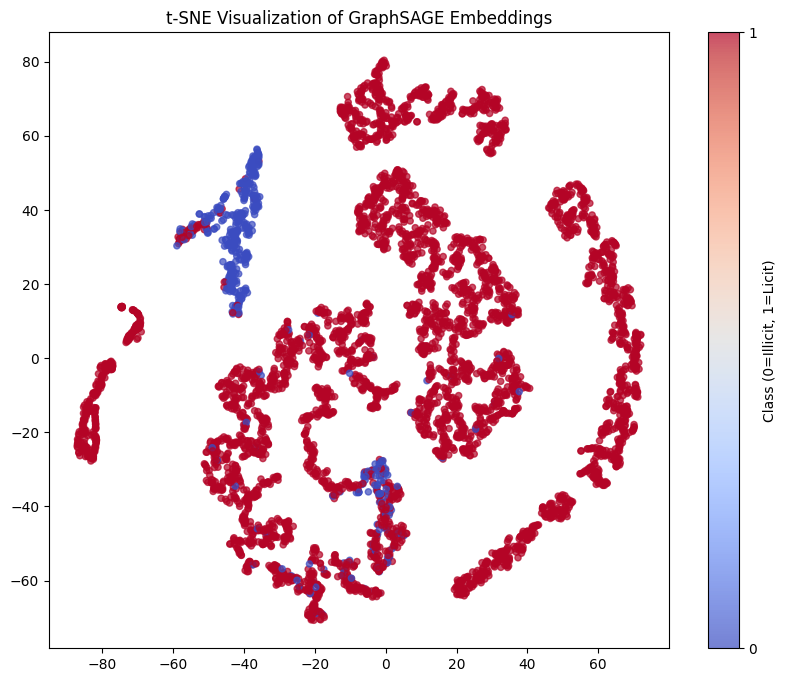

In [182]:
from sklearn.manifold import TSNE

best_model = sage
best_model.eval()

with torch.no_grad():
    logits = best_model(data.x, data.edge_index)
    embeddings = logits.cpu().numpy()


mask = (data.y != -1).cpu().numpy()
indices = np.where(mask)[0]

if len(indices) > 5000:
    np.random.shuffle(indices)
    indices = indices[:5000]

X_emb = embeddings[indices]
y_emb = data.y.cpu().numpy()[indices]


tsne = TSNE(n_components=2, random_state=42, init='random', learning_rate=200)
X_tsne = tsne.fit_transform(X_emb)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_emb, cmap='coolwarm', alpha=0.7, s=20)
plt.colorbar(scatter, ticks=[0, 1], label='Class (0=Illicit, 1=Licit)')
plt.title('t-SNE Visualization of GraphSAGE Embeddings')
plt.show()

In [181]:
import time
import numpy as np
import torch

seeds = [42, 100, 2024, 7, 99]
f1_scores = []
train_times = []


for seed in seeds:
    torch.manual_seed(seed)
    
    model = GraphSAGE(data.num_features, 64, 2, dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    start_time = time.time()
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
    end_time = time.time()
    
    _, val_f1, _, _ = evaluate(model, data)
    f1_scores.append(val_f1)
    train_times.append(end_time - start_time)

print(f"Mean F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Avg Training Time (100 epochs): {np.mean(train_times):.4f} seconds")


Mean F1 Score: 0.7236 ± 0.0087
Avg Training Time (100 epochs): 2.4299 seconds


## Correct & misclassified examples

In [ ]:
#TP / TN / FP / FN node IDs with confidence (GraphSAGE) 
import os


data = torch.load(os.path.join(DATA_DIR, "elliptic_graph.pt"), map_location=device)


sage = GraphSAGE(in_channels=data.num_features, hidden_channels=64, out_channels=2, dropout=0.5).to(device)
sage_ckpt = os.path.join(MODEL_DIR, "models/graphsage_best.pt")
sage.load_state_dict(torch.load(sage_ckpt, map_location=device))
sage.eval()


mask = data.test_mask & (data.y != -1)
with torch.no_grad():
    logits = sage(data.x, data.edge_index)
    probs = torch.softmax(logits, dim=1)

y_true = data.y[mask].cpu().numpy()
y_pred = logits[mask].argmax(dim=1).cpu().numpy()
conf   = probs[mask].max(dim=1).values.cpu().numpy()


ILLICIT = 0
LICIT   = 1

tp = np.where((y_true == ILLICIT) & (y_pred == ILLICIT))[0]
tn = np.where((y_true == LICIT)   & (y_pred == LICIT))[0]
fp = np.where((y_true == LICIT)   & (y_pred == ILLICIT))[0] 
fn = np.where((y_true == ILLICIT) & (y_pred == LICIT))[0] 

def topk_examples(idx_arr, k=10):
    if len(idx_arr) == 0:
        return []

    idx_sorted = idx_arr[np.argsort(-conf[idx_arr])]
    return [(int(i), float(conf[i]), int(y_true[i]), int(y_pred[i])) for i in idx_sorted[:k]]

print("TP (illicit→illicit):", topk_examples(tp, 10))
print("TN (licit→licit):",   topk_examples(tn, 10))
print("FP (licit→illicit):", topk_examples(fp, 10))
print("FN (illicit→licit):", topk_examples(fn, 10))


C:\Users\henry\AppData\Local\Temp\ipykernel_27256\670785895.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(DATA_DIR, "elliptic_graph.pt")

TP (illicit→illicit): [(6756, 0.9983853101730347, 0, 0), (6647, 0.9982750415802002, 0, 0), (2515, 0.9970075488090515, 0, 0), (7219, 0.9967843294143677, 0, 0), (2804, 0.9952443242073059, 0, 0), (2083, 0.9951027631759644, 0, 0), (7450, 0.9949146509170532, 0, 0), (2734, 0.9945530295372009, 0, 0), (2962, 0.9944420456886292, 0, 0), (2111, 0.9942821264266968, 0, 0)]
TN (licit→licit): [(0, 1.0, 1, 1), (22, 1.0, 1, 1), (21, 1.0, 1, 1), (20, 1.0, 1, 1), (19, 1.0, 1, 1), (18, 1.0, 1, 1), (17, 1.0, 1, 1), (16, 1.0, 1, 1), (9281, 1.0, 1, 1), (45, 1.0, 1, 1)]
FP (licit→illicit): [(5766, 0.9749360084533691, 1, 0), (3683, 0.9416007399559021, 1, 0), (5102, 0.8831270337104797, 1, 0), (5331, 0.8791974782943726, 1, 0), (4358, 0.868995189666748, 1, 0), (5637, 0.8134135603904724, 1, 0), (3578, 0.7978096008300781, 1, 0), (3620, 0.7918146848678589, 1, 0), (6606, 0.7817290425300598, 1, 0), (4615, 0.7760148644447327, 1, 0)]
FN (illicit→licit): [(7445, 1.0, 0, 1), (8794, 1.0, 0, 1), (7884, 0.9999992847442627, 0